In [54]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from typing import TypedDict 
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.output_parsers import SimpleJsonOutputParser

from pydantic import BaseModel,Field

import operator
from typing import Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import Literal

load_dotenv()

True

In [55]:
llm1=ChatGroq(
    model="llama-3.3-70b-versatile"
)

llm2=ChatGroq(
    model="llama-3.3-70b-versatile"
)

llm3=ChatGroq(
    model="llama-3.3-70b-versatile"
)


In [56]:
class TwitState(TypedDict):
    topic:str
    twit:str
    feedback:str
    evaluation:Literal['approved','not_approved']
    iteration:int 
    max_iteration:int
    


class structured_Schema(BaseModel):
    evaluation:Literal['approved','not_approved']
    feedback: str = Field(..., description="feedback for the tweet.")




In [57]:
structured_llm=llm2.with_structured_output(structured_Schema)

In [58]:
def twit_genrater(state:TwitState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".
        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        - This is version {state['iteration'] + 1}.
        """)
    ]


    twit=llm1.invoke(messages).content

    return {'twit':twit}


def twit_evaluater(state:TwitState):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['twit']}"

    Use the criteria below to evaluate the tweet:

    1. Originality – Is this fresh, or have you seen it a hundred times before?  
    2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness – Is it short, sharp, and scroll-stopping?  
    4. Virality Potential – Would people retweet or share it?  
    5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

    ### Respond ONLY in structured format:
    - evaluation: "approved" or "not_approved"  
    - feedback: One paragraph explaining the strengths and weaknesses 
    """)
    ]

    response = structured_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback}


def twit_optimizer(state:TwitState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Tweet:
    {state['twit']}

    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """)
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'twit': response, 'iteration': iteration}

def route_evaluation(state:TwitState):
    if state['evaluation']=='approved' or state['max_iteration']==state['iteration'] : return 'approved'
    else : return 'not_approved'


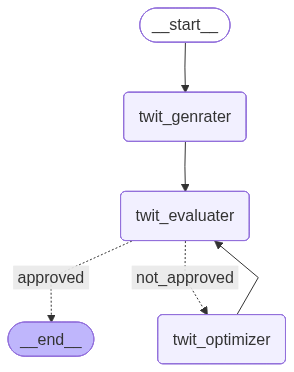

In [59]:
graph=StateGraph(TwitState)

graph.add_node('twit_genrater',twit_genrater)
graph.add_node('twit_evaluater',twit_evaluater)
graph.add_node('twit_optimizer',twit_optimizer)


graph.add_edge(START,'twit_genrater')
graph.add_edge('twit_genrater','twit_evaluater')
graph.add_conditional_edges('twit_evaluater', route_evaluation, {'approved': END, 'not_approved': 'twit_optimizer'})
graph.add_edge('twit_optimizer','twit_evaluater')
workflow=graph.compile()
graph.compile()


In [66]:
initial_state = {
    "topic": "mobile use",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [67]:
result

{'topic': 'mobile use',
 'twit': '"My phone battery lasts longer than my attention span"',
 'feedback': "This tweet is a gem. It's original, humorous, and punchy, making it a scroll-stopping masterpiece. The comparison between phone battery life and attention span is fresh and relatable, inducing a genuine smile. The tweet is well-formed, under 280 characters, and doesn't follow a traditional setup-punchline joke format. Its virality potential is high, as people can easily identify with the sentiment and will likely retweet or share it. Overall, this tweet checks all the right boxes, making it a strong contender for going viral.",
 'evaluation': 'approved',
 'iteration': 1,
 'max_iteration': 5}